# EDA 10 v5 — Figure 4.5: mechanism geography with selected diagnostic cases

**Revised 2026-07-29.** This version removes the earlier implication that the
`outflow-internal-majority` leaf is itself a national-ladder artefact. The leaf
is retained as a neutral measured profile because the later Yee & Dennett
comparison shows that it also contains a concentration of super-gentrification
locations. Any distinction between ladder-sensitive and substantively meaningful
variants is therefore deferred to the case decompositions and Discussion chapter.

| Figure | Section | Fills | Yee markers | Case outlines/labels |
|---|---|---|---|---|
| **4.5 (this notebook)** | end of §4.5 | full six-class mechanism background | **none** | **yes — nine diagnostic cases** |
| 4.7 / correspondence map | §4.6 | same fills and palette | purple SupGen/MainGen | none |

**Design decisions:**
- The full six-class mechanism background is retained.
- Both panels show the same nine labelled MSOAs, allowing colour changes to be
  followed directly between 2011 and 2021.
- Case labels identify diagnostic examples only; they do **not** define the
  substantive meaning of an entire mechanism leaf.
- Harrow 008 and Harrow 029 are described neutrally as outer-London
  `outflow-internal-majority` examples, not as proof that the whole leaf is an artefact.
- The final Figure 4.6 case-decomposition notebook should include an inner-London
  `outflow-internal-majority` case associated with the super-gentrification overlap,
  alongside an outer-London example, once that case is selected from the joined data.

**Inputs:** `data/london_msoa_2011.geojson`,
`outputs/eda9_mechanism_tree_20260705.csv` (or the inline fallback), and
`data/MSOA_2011_to_2021_lookup_for_identification.csv`.

**Output:** `outputs/case_study/locator_map/fig_eda10_v5_mechanism_case_locator_20260729.png`


In [1]:
# ── imports & paths (verbatim conventions from eda_10fixed) ──────────────────
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
from shapely.geometry import shape
from shapely.ops import unary_union
from pyprojroot import here

plt.rcParams['font.family'] = 'DejaVu Sans'

ROOT       = here()
sys.path.insert(0, str(ROOT))

DATA_DIR   = ROOT / 'data'
OUT_DIR    = ROOT / 'outputs' / 'case_study' / 'locator_map'
BOUNDARIES = DATA_DIR / 'london_msoa_2011.geojson'
EDA4       = ROOT / 'outputs' / 'eda4_results_for_phase3_20260626.csv'
NATF       = DATA_DIR / 'msoa_cascade_national_frame_20260625.csv'
EDA9       = ROOT / 'outputs' / 'eda9_mechanism_tree_20260705.csv'
LOOKUP     = DATA_DIR / 'MSOA_2011_to_2021_lookup_for_identification.csv'
OUT_PNG    = OUT_DIR / 'fig_eda10_v5_mechanism_case_locator_20260729.png'

OUT_DIR.mkdir(parents=True, exist_ok=True)

INNER_LONDON_LADS = {
    'E09000007','E09000001','E09000011','E09000012','E09000013',
    'E09000014','E09000019','E09000020','E09000022','E09000023',
    'E09000025','E09000028','E09000030','E09000032','E09000033',
}

In [2]:
# ── EDA 9 mechanism classes (single interface; inline fallback) ──────────────
INFLOW_MIN = 0.25
EXT_MAJ    = 0.50
LEAVES     = ['inflow-driven', 'frame-sensitive', 'outflow-external', 'outflow-internal']

def _leaf(r, yr):
    if r[f'Typ_C_{yr}'] != 'Cascade-led':
        return None
    if r[f'Casc_Inflow_Share_{yr}'] >= INFLOW_MIN:
        return 'inflow-driven' if r[f'Typ_A_{yr}'] == 'Cascade-led' else 'frame-sensitive'
    return 'outflow-external' if r[f'Ext_Arm_Share_{yr}'] >= EXT_MAJ else 'outflow-internal'

if EDA9.exists():
    e9 = pd.read_csv(EDA9)
    rename = {'frame-sensitive inflow': 'frame-sensitive',
              'outflow: external-majority': 'outflow-external',
              'outflow: internal-majority': 'outflow-internal'}
    for yr in ('11', '21'):
        e9[f'leaf_{yr}'] = e9[f'leaf_{yr}'].replace(rename)
    print(f'loaded mechanism classes from {EDA9.name}')
else:
    e4 = pd.read_csv(EDA4)
    nf = pd.read_csv(NATF)
    e9 = e4.merge(nf[['msoa11cd',
                      'Outflow_Poorer_nat_11', 'Ext_Outflow_nat_11',
                      'Outflow_Poorer_nat_21', 'Ext_Outflow_nat_21']],
                  on='msoa11cd', validate='1:1')
    for yr in ('11', '21'):
        arm = e9[f'Outflow_Poorer_nat_{yr}'].replace(0, np.nan)
        e9[f'Ext_Arm_Share_{yr}'] = np.where(e9['Wealth_Decile_National'] > 6,
                                             e9[f'Ext_Outflow_nat_{yr}'] / arm, 0.0)
        e9[f'Ext_Arm_Share_{yr}'] = e9[f'Ext_Arm_Share_{yr}'].fillna(0.0)
        e9[f'leaf_{yr}'] = e9.apply(_leaf, axis=1, yr=yr)
    print('EDA 9 export not found — computed mechanism tree inline (identical rules)')

# guard: EDA 9 leaf counts
assert e9['leaf_11'].value_counts().to_dict() == {'outflow-internal': 81, 'frame-sensitive': 57,
                                                  'inflow-driven': 56, 'outflow-external': 19}
assert e9['leaf_21'].value_counts().to_dict() == {'outflow-internal': 90, 'outflow-external': 78,
                                                  'frame-sensitive': 14, 'inflow-driven': 13}
print('leaf counts reproduce EDA 9 exactly')

loaded mechanism classes from eda9_mechanism_tree_20260705.csv
leaf counts reproduce EDA 9 exactly


In [3]:
# ── colour grammar: flow_yee_palette_v2 (same fills as Figure 4.6) ─────────
try:
    from flow_yee_palette_v2 import FLOW_FILL, FLOW_ALPHA, FLOW_DRAW_ORDER, FLOW_LABEL
    print('palette v2.1 imported from flow_yee_palette_v2.py')
except ImportError:
    print('flow_yee_palette_v2.py not found at project root — inline fallback '
          '(identical values; place the module at ROOT so Figures 4.5/4.6 share it)')
    FLOW_FILL = {'inflow-driven': '#99000d', 'frame-sensitive': '#e6ab02',
                 'outflow-external': '#e64a2e', 'outflow-internal': '#f8875f',
                 'counter': '#9db8ce', 'other': '#e9e7e2'}
    FLOW_ALPHA = {'inflow-driven': 0.95, 'frame-sensitive': 0.90,
                  'outflow-external': 0.95, 'outflow-internal': 0.95,
                  'counter': 0.85, 'other': 1.00}
    FLOW_DRAW_ORDER = ('other', 'counter', 'outflow-internal',
                       'outflow-external', 'frame-sensitive', 'inflow-driven')
    FLOW_LABEL = {'inflow-driven': 'Inflow-driven cascade — frame-robust, inflow-led',
                  'frame-sensitive': 'Frame-sensitive inflow — residual',
                  'outflow-external': 'Outflow cascade — external-majority',
                  'outflow-internal': 'Outflow cascade — internal-majority',
                  'counter': 'Counter-led', 'other': 'Symmetric / Lateral'}

palette v2.1 imported from flow_yee_palette_v2.py


In [4]:
# ── case roster: same labelled cases in both panels ─────────────────────────
# These are diagnostic examples, not exhaustive representatives of each leaf.
# In particular, the outflow-internal-majority leaf is not labelled as an
# artefact here: Section 4.6 shows that super-gentrification locations are also
# concentrated in this profile.

CASES_INFLOW_ROBUST = {
    'E02000191': 'Camden 026',
    'E02000873': 'Tower Hamlets 010',
}

CASES_TEMPORAL_CHANGE = {
    'E02000809': 'Southwark 003',
    'E02000561': 'Islington 008',
    'E02000957': 'Wandsworth 035',
}

CASES_OUTFLOW_INTERNAL_OUTER = {
    'E02000440': 'Harrow 008',
    'E02000461': 'Harrow 029',
}

CASES_OUTFLOW_EXTERNAL = {
    'E02000616': 'Kingston upon Thames 019',
    'E02000237': 'Croydon 044',
}

# NOTE FOR FIGURE 4.6:
# Add one inner-London outflow-internal-majority MSOA that overlaps a SupGen
# indicator. That case should be selected from the joined mechanism–Yee table,
# rather than inferred from geography alone. The locator can then be updated by
# adding its code/name here and a label offset below.

CASES_ALL = {
    **CASES_INFLOW_ROBUST,
    **CASES_TEMPORAL_CHANGE,
    **CASES_OUTFLOW_INTERNAL_OUTER,
    **CASES_OUTFLOW_EXTERNAL,
}
CASES_BY_YEAR = {'11': CASES_ALL, '21': CASES_ALL}

LABEL_OFF = {
    'Camden 026':        (-0.115,  0.016),
    'Tower Hamlets 010': ( 0.105,  0.026),
    'Southwark 003':     ( 0.095, -0.052),
    'Islington 008':     ( 0.090,  0.040),
    'Wandsworth 035':    (-0.035, -0.062),
    'Harrow 008':        ( 0.088,  0.032),
    'Harrow 029':        (-0.095, -0.034),
    'Kingston upon Thames 019': (-0.095, -0.045),
    'Croydon 044':       ( 0.090, -0.040),
}

LABEL_YEARS = {name: ('11', '21') for name in CASES_ALL.values()}


In [5]:
# ── geometry (verbatim from eda_10fixed): WGS84 geojson + LAD22 inner union ──
gj = json.load(open(BOUNDARIES))
geoms, codes = [], []
for ft in gj['features']:
    geoms.append(shape(ft['geometry']))
    codes.append(ft['properties']['MSOA11CD'])

def rings(geom):
    if geom.geom_type == 'Polygon':
        polys = [geom]
    elif geom.geom_type == 'MultiPolygon':
        polys = geom.geoms
    elif geom.geom_type == 'GeometryCollection':
        polys = [g for g in geom.geoms if g.geom_type == 'Polygon']
    else:
        polys = []
    return [np.asarray(p.exterior.coords) for p in polys]

lookup = pd.read_csv(LOOKUP, encoding='utf-8-sig')          # first column has a BOM
msoa2lad = dict(zip(lookup['MSOA11CD'], lookup['LAD22CD']))
lads = [msoa2lad.get(c, '') for c in codes]

london = unary_union(geoms)
inner  = unary_union([g for g, l in zip(geoms, lads) if l in INNER_LONDON_LADS])
assert not inner.is_empty, 'Inner London union came back empty — check LAD mapping'
print(f'{len(geoms)} MSOA geometries loaded')

983 MSOA geometries loaded


In [6]:
# ── per-year six-class map categories (fig2 logic from eda_10fixed) ──────────
def fig_class(r, yr):
    if isinstance(r[f'leaf_{yr}'], str):
        return r[f'leaf_{yr}']
    return 'counter' if r[f'Typ_C_{yr}'] == 'Counter-led' else 'other'

cat, counts = {}, {}
for yr in ('11', '21'):
    e9[f'figcls_{yr}'] = e9.apply(fig_class, axis=1, yr=yr)
    d = dict(zip(e9['msoa11cd'], e9[f'figcls_{yr}']))
    d['E02000190'] = d.get('E02000189', 'other')            # Camden 024/025 merge
    cat[yr] = d
    counts[yr] = e9[f'figcls_{yr}'].value_counts()
    print(f'20{yr}:', counts[yr].to_dict())

2011: {'other': 489, 'counter': 280, 'outflow-internal': 81, 'frame-sensitive': 57, 'inflow-driven': 56, 'outflow-external': 19}
2021: {'counter': 452, 'other': 335, 'outflow-internal': 90, 'outflow-external': 78, 'frame-sensitive': 14, 'inflow-driven': 13}


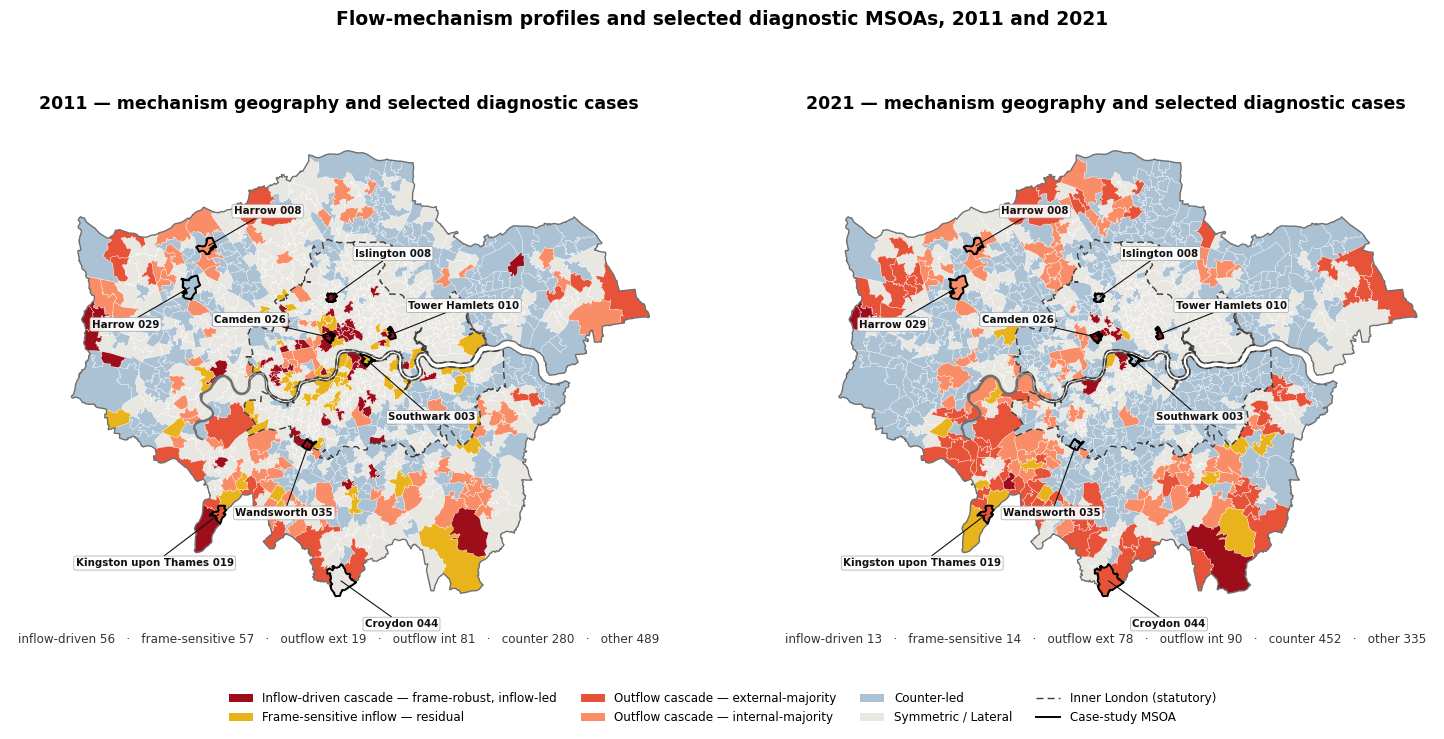

saved /Users/xing/Desktop/CASA/dissertation/outputs/case_study/locator_map/fig_eda10_v5_mechanism_case_locator_20260729.png


In [7]:
# ── Figure 4.5: two-panel mechanism geography with case exemplars ────────────
TITLES = {'11': '2011 — mechanism geography and selected diagnostic cases',
          '21': '2021 — mechanism geography and selected diagnostic cases'}

fig, axes = plt.subplots(1, 2, figsize=(15.5, 7.4))

for ax, yr in zip(axes, ('11', '21')):
    for c in FLOW_DRAW_ORDER:
        polys = [r for g, code in zip(geoms, codes)
                 if cat[yr].get(code, 'other') == c for r in rings(g)]
        if polys:
            ax.add_collection(PolyCollection(polys, facecolor=FLOW_FILL[c],
                                             edgecolor='white', linewidth=0.25,
                                             alpha=FLOW_ALPHA[c], zorder=2))
    for r in rings(london):
        ax.plot(r[:, 0], r[:, 1], color='#6f6f6f', lw=1.0, zorder=5)
    for r in rings(inner):
        ax.plot(r[:, 0], r[:, 1], color='#3d3d3d', lw=1.0, ls=(0, (5, 3)), zorder=5)

    fs = 7.4                          # both panels carry all nine labels
    for code, name in CASES_BY_YEAR[yr].items():
        g = geoms[codes.index(code)]
        ax.add_collection(PolyCollection(rings(g), facecolor='none',
                                         edgecolor='black', linewidth=1.4, zorder=6))
        if yr in LABEL_YEARS.get(name, ()):
            cx, cy = g.centroid.x, g.centroid.y
            dx, dy = LABEL_OFF[name]
            ax.annotate(name, xy=(cx, cy), xytext=(cx + dx, cy + dy),
                        fontsize=fs, fontweight='bold', color='#111',
                        ha='center', va='center', zorder=8,
                        arrowprops=dict(arrowstyle='-', color='#111', lw=0.8,
                                        shrinkA=0, shrinkB=1),
                        bbox=dict(boxstyle='round,pad=0.18', fc='white',
                                  ec='#999', lw=0.5, alpha=0.9))

    n = counts[yr]
    ax.set_title(TITLES[yr], fontsize=12.5, fontweight='bold', pad=8)
    ax.text(0.5, -0.015,
            f"inflow-driven {n.get('inflow-driven',0)}   ·   frame-sensitive {n.get('frame-sensitive',0)}   ·   "
            f"outflow ext {n.get('outflow-external',0)}   ·   outflow int {n.get('outflow-internal',0)}   ·   "
            f"counter {n.get('counter',0)}   ·   other {n.get('other',0)}",
            transform=ax.transAxes, ha='center', va='top', fontsize=8.6, color='#333')
    ax.set_aspect(1.0 / np.cos(np.radians(51.5)))
    ax.set_xlim(-0.60, 0.36); ax.set_ylim(51.26, 51.72)
    ax.set_axis_off()

handles = ([mpatches.Patch(fc=FLOW_FILL[c], alpha=FLOW_ALPHA[c], label=FLOW_LABEL[c])
            for c in ('inflow-driven', 'frame-sensitive', 'outflow-external',
                      'outflow-internal', 'counter', 'other')] +
           [Line2D([0], [0], color='#3d3d3d', lw=1.0, ls=(0, (5, 3)),
                   label='Inner London (statutory)'),
            Line2D([0], [0], color='black', lw=1.4, label='Case-study MSOA')])
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
           fontsize=8.6, bbox_to_anchor=(0.5, 0.005))

fig.suptitle('Flow-mechanism profiles and selected diagnostic MSOAs, 2011 and 2021',
             fontsize=13.5, fontweight='bold', y=0.985)

plt.tight_layout(rect=[0, 0.085, 1, 0.95])
plt.savefig(OUT_PNG, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'saved {OUT_PNG}')

## Draft caption (end of §4.5)

> **Figure 4.5. Spatial distribution of Frame C mechanism profiles and selected
> diagnostic MSOAs, 2011 and 2021.** Area fills show the six-class flow
> classification from the time-symmetric mechanism tree; warm hues identify the
> four Frame C Cascade-led mechanism leaves, blue identifies Counter-led areas,
> and grey identifies Symmetric/Lateral areas. Both panels outline and label the
> same nine MSOAs so that changes in their classifications can be followed across
> the two census periods. The labelled areas are diagnostic examples and do not
> define the substantive meaning of an entire mechanism profile. Full flow
> decompositions are reported in Figure 4.6 and Appendix X.

## Interpretation guardrail

- Do not call the complete `outflow-internal-majority` leaf a **national-ladder
  artefact** in the map title, legend, caption or Results prose.
- Harrow 008 and Harrow 029 may be described as outer-London examples whose
  classifications are strongly outflow-dominated, but they are not evidence that
  every member of the leaf has the same explanation.
- Figure 4.6 should contrast an outer-London outflow-internal example with an
  inner-London outflow-internal case that overlaps the SupGen indicator. This
  preserves the heterogeneity subsequently reported in Section 4.6.
- The colour scheme remains identical to the correspondence map.
